#  Experiment 10: Music Generation

## The Grand Finale: Generate New Music!

**Objective:** Use the trained QCBM to generate novel musical sequences and export them as MIDI files.

**What We'll Do:**
1. Load the trained champion model
2. Sample from the quantum distribution
3. Decode samples to musical notes
4. Generate MIDI files
5. Analyze generated vs original music

---

In [1]:
# Setup
import sys
sys.path.insert(0, '..')

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from src.models.qcbm import QCBM, create_entangled_qcbm
from src.data.encoder import PitchEncoder
from src.data.midi_parser import MidiParser, export_to_midi, Note
from src.utils.visualization import set_style
from src.utils.figure_saver import save_figure
from config import FIGURES_DIR, RANDOM_SEED

set_style()
np.random.seed(RANDOM_SEED)
print(" Setup complete!")

 Setup complete!


## 1. Load Trained Model

In [2]:
# Try to load champion parameters from previous experiment
try:
    champion_params = np.load(FIGURES_DIR / 'champion_params.npy')
    print(f" Loaded champion parameters: {len(champion_params)} values")
except FileNotFoundError:
    print(" Champion params not found - will train a quick model")
    champion_params = None

# Create the QCBM model
N_QUBITS = 4  # For pitch only
N_LAYERS = 3

qcbm = create_entangled_qcbm(n_qubits=N_QUBITS, n_layers=N_LAYERS)
print(f"\n Model: {qcbm}")
print(f"   Parameters: {qcbm.n_params}")

 Loaded champion parameters: 48 values

 Model: QCBM(n_qubits=4, n_layers=3, topology='full')
   Parameters: 24


## 2. Quick Training (if needed)

In [3]:
# Load champion configuration from experiments
import json

with open(FIGURES_DIR / 'exp07_optimizer_results.json') as f:
    exp07 = json.load(f)
    CHAMPION_OPTIMIZER = exp07['winner']

with open(FIGURES_DIR / 'exp06_topology_results.json') as f:
    exp06 = json.load(f)
    CHAMPION_TOPOLOGY = exp06['winner']

print(f" Champion Configuration:")
print(f"   Topology: {CHAMPION_TOPOLOGY}")
print(f"   Optimizer: {CHAMPION_OPTIMIZER}")
print(f"   Loss: MMD (from exp08)")

 Champion Configuration:
   Topology: linear
   Optimizer: SLSQP
   Loss: MMD (from exp08)


In [4]:
# If no pre-trained params, train on Mario data
if champion_params is None or len(champion_params) != qcbm.n_params:
    print(" Training model on Mario data...")
    
    # Load Mario data
    from src.data.datasets import get_mario_dataset
    from src.training.trainer import train_qcbm
    
    dataset = get_mario_dataset(n_qubits=N_QUBITS)
    result = train_qcbm(
        qcbm=qcbm,
        target_distribution=dataset.distribution,
        n_iterations=200,
        loss_function='mmd',  # Champion from exp08
        optimizer=CHAMPION_OPTIMIZER,  # Champion from exp07
        verbose=True,
        seed=RANDOM_SEED
    )
    champion_params = result.final_params
    print(f"\n Training complete! Final fidelity: {result.final_fidelity:.4f}")
else:
    print(" Using pre-trained parameters")

 Training model on Mario data...


Training QCBM:   0%|          | 0/200 [00:00<?, ?it/s]/home/jacopo/Documenti/Trento/QuantumML/MusicProject/notebooks/../src/training/trainer.py:206: OptimizeWarning: Unknown solver options: maxfev
  result = minimize(
Training QCBM:   2%|▏         | 3/200 [00:00<00:01, 132.56it/s, loss=0.1690, fidelity=0.7919]/home/jacopo/Documenti/Trento/QuantumML/MusicProject/notebooks/../src/training/trainer.py:206: OptimizeWarning: Unknown solver options: maxfev
  result = minimize(
Training QCBM: 750it [00:05, 143.88it/s, loss=0.0001, fidelity=0.9516]                         


 Training complete! Final fidelity: 0.9516


## 3. Setup Encoder

In [5]:
# Load original Mario data to get pitch range
parser = MidiParser('../mario.mid')
parser.parse()  # Parse the MIDI file
original_notes = parser.notes
original_pitches = [n.pitch for n in original_notes]

print(f" Loaded Mario MIDI:")
print(f"   Total notes: {len(original_notes)}")

# Create encoder
encoder = PitchEncoder(n_qubits=N_QUBITS)
encoder.fit(original_pitches)

print(f"\n Pitch Range Analysis:")
print(f"   Original range: {min(original_pitches)} - {max(original_pitches)}")
print(f"   Encoder bins: {encoder.n_bins}")
print(f"   Bin width: {encoder.bin_width:.2f} semitones")

 Loaded Mario MIDI:
   Total notes: 5435

 Pitch Range Analysis:
   Original range: 26 - 95
   Encoder bins: 16
   Bin width: 4.38 semitones


## 4. Sample from QCBM

 Figure saved: /home/jacopo/Documenti/Trento/QuantumML/MusicProject/notebooks/../results/figures/exp10_learned_pitch_distribution.png


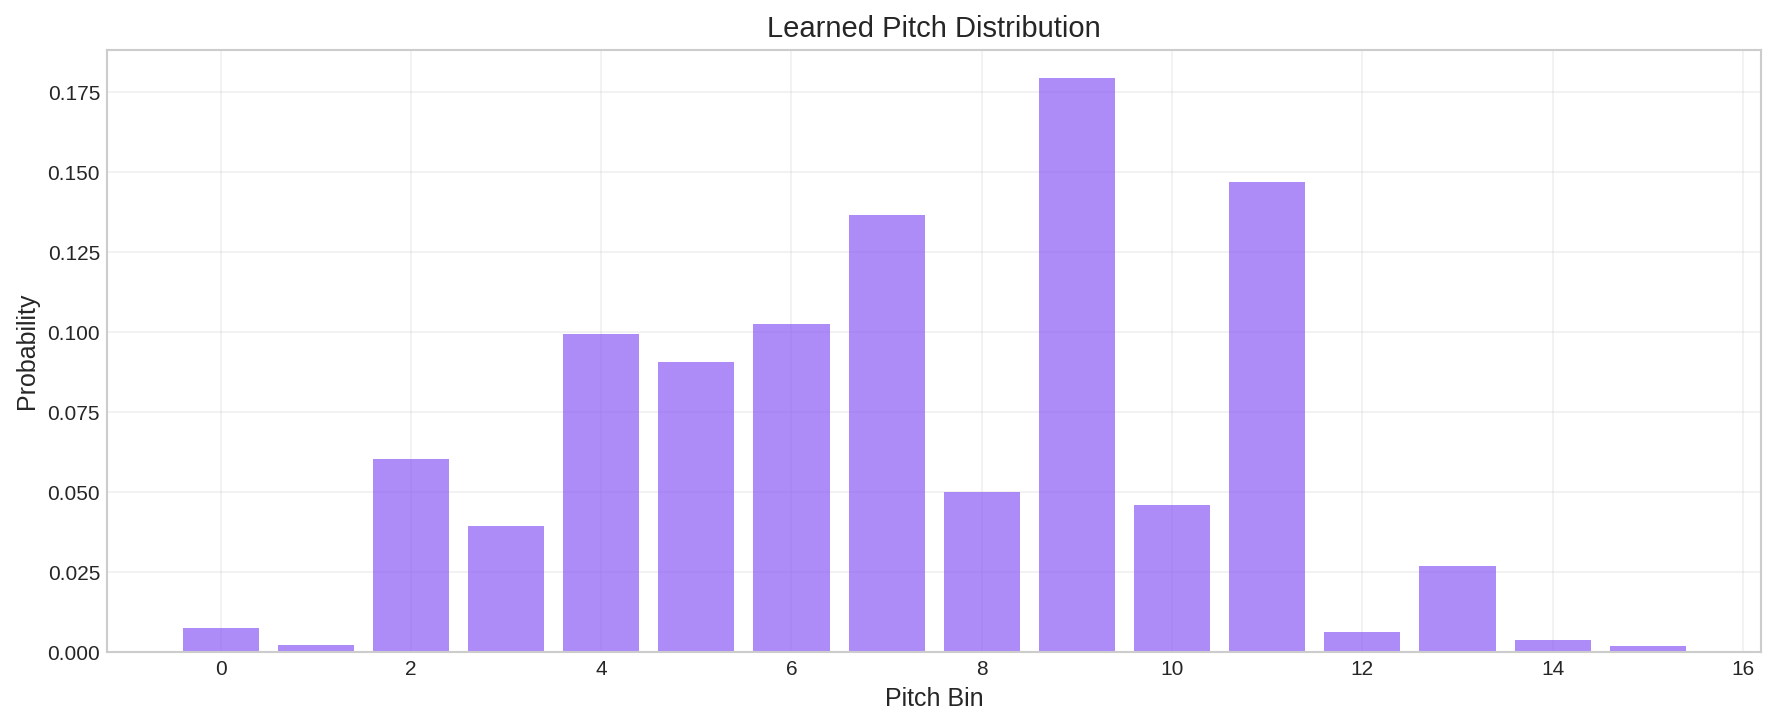


 Distribution Statistics:
   Non-zero bins: 11
   Max probability: 0.1793
   Entropy: 3.38 bits


In [6]:
# Get the learned distribution
learned_probs = qcbm.get_probabilities(champion_params)

# Visualize learned distribution
fig, ax = plt.subplots(figsize=(12, 5))
bins = np.arange(len(learned_probs))
ax.bar(bins, learned_probs, color='#8B5CF6', alpha=0.7)
ax.set_xlabel('Pitch Bin')
ax.set_ylabel('Probability')
ax.set_title('Learned Pitch Distribution')
ax.grid(True, alpha=0.3)
plt.tight_layout()
save_figure(fig, 'learned_pitch_distribution', experiment='exp10')
plt.show()

print(f"\n Distribution Statistics:")
print(f"   Non-zero bins: {np.sum(learned_probs > 0.01)}")
print(f"   Max probability: {np.max(learned_probs):.4f}")
print(f"   Entropy: {-np.sum(learned_probs * np.log2(learned_probs + 1e-10)):.2f} bits")

In [7]:
# Sample notes
N_SAMPLES = 100

samples = qcbm.sample(champion_params, n_samples=N_SAMPLES)
print(f" Generated {N_SAMPLES} samples")
print(f"   Unique values: {len(np.unique(samples))}")
print(f"   Sample values: {samples[:20]}")

 Generated 100 samples
   Unique values: 13
   Sample values: [ 7 10  4  7  9  2  9  4  2 11 12 10  6  3  9  7  4  7  2 11]


## 5. Decode to Musical Notes

 Decoded Pitches:
   Range: 28.1875 - 85.0625
   First 20: [np.float64(58.8125), np.float64(71.9375), np.float64(45.6875), np.float64(58.8125), np.float64(67.5625), np.float64(36.9375), np.float64(67.5625), np.float64(45.6875), np.float64(36.9375), np.float64(76.3125), np.float64(80.6875), np.float64(71.9375), np.float64(54.4375), np.float64(41.3125), np.float64(67.5625), np.float64(58.8125), np.float64(45.6875), np.float64(58.8125), np.float64(36.9375), np.float64(76.3125)]
 Figure saved: /home/jacopo/Documenti/Trento/QuantumML/MusicProject/notebooks/../results/figures/exp10_pitch_comparison.png
 Figure saved: /home/jacopo/Documenti/Trento/QuantumML/MusicProject/notebooks/../results/figures/exp10_pitch_comparison.png


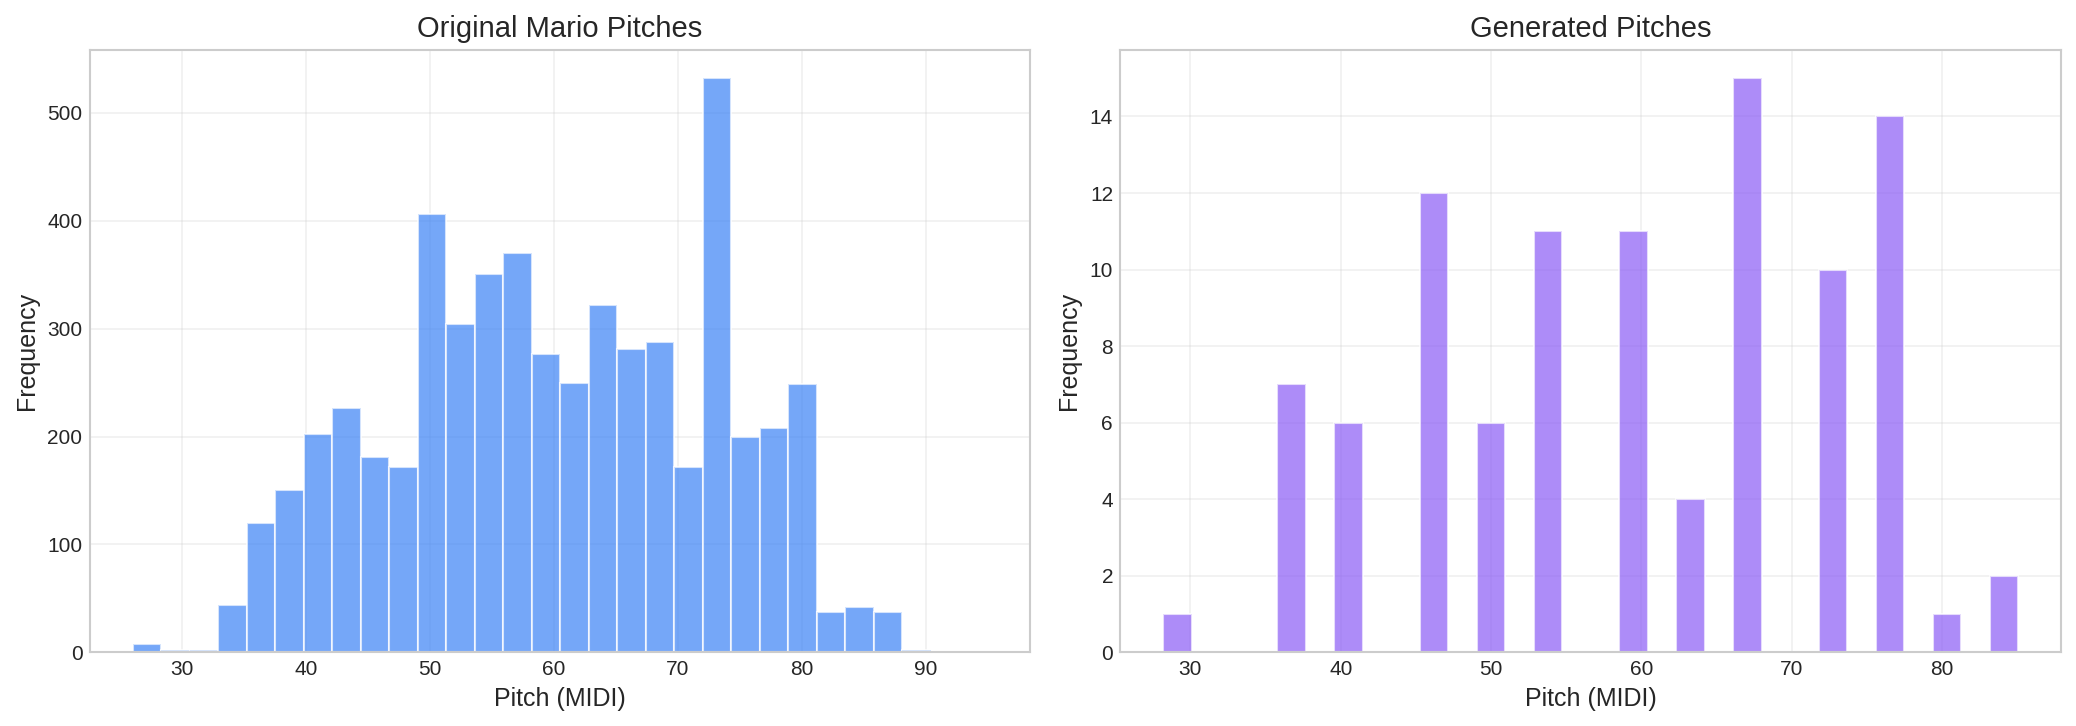

In [8]:
# Decode samples to pitches
generated_pitches = [encoder.decode(s) for s in samples]

print(f" Decoded Pitches:")
print(f"   Range: {min(generated_pitches)} - {max(generated_pitches)}")
print(f"   First 20: {generated_pitches[:20]}")

# Compare with original
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Original histogram
axes[0].hist(original_pitches, bins=30, color='#3B82F6', alpha=0.7, edgecolor='white')
axes[0].set_xlabel('Pitch (MIDI)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Original Mario Pitches')
axes[0].grid(True, alpha=0.3)

# Generated histogram
axes[1].hist(generated_pitches, bins=30, color='#8B5CF6', alpha=0.7, edgecolor='white')
axes[1].set_xlabel('Pitch (MIDI)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Generated Pitches')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
save_figure(fig, 'pitch_comparison', experiment='exp10')
plt.show()

## 6. Create Notes with Musical Structure

In [9]:
def create_melody(pitches, tempo=120, note_duration=0.5):
    """
    Convert list of pitches to Note objects with timing.
    
    Args:
        pitches: List of MIDI pitch values
        tempo: BPM (beats per minute)
        note_duration: Duration of each note in beats
    
    Returns:
        List of Note objects
    """
    seconds_per_beat = 60.0 / tempo
    notes = []
    
    for i, pitch in enumerate(pitches):
        note = Note(
            pitch=pitch,
            velocity=80,  # Medium velocity
            start_time=i * note_duration * seconds_per_beat,
            duration=note_duration * seconds_per_beat * 0.9  # Slight gap
        )
        notes.append(note)
    
    return notes

# Create melody from generated pitches
generated_notes = create_melody(generated_pitches, tempo=120, note_duration=0.25)

print(f" Created {len(generated_notes)} notes")
print(f"   Total duration: {generated_notes[-1].start_time + generated_notes[-1].duration:.2f} seconds")
print(f"\n   First 5 notes:")
for note in generated_notes[:5]:
    print(f"   - Pitch: {note.pitch}, Start: {note.start_time:.3f}s")

 Created 100 notes
   Total duration: 12.49 seconds

   First 5 notes:
   - Pitch: 58.8125, Start: 0.000s
   - Pitch: 71.9375, Start: 0.125s
   - Pitch: 45.6875, Start: 0.250s
   - Pitch: 58.8125, Start: 0.375s
   - Pitch: 67.5625, Start: 0.500s


## 7. Export to MIDI

In [10]:
# Export generated melody
output_path = FIGURES_DIR / '01_qcbm_champion_baseline.mid'
export_to_midi(generated_notes, str(output_path), tempo=120)

print(f" MIDI file exported: {output_path}")
print(f"\n   You can now open this file in any MIDI player or DAW!")

 MIDI file exported: /home/jacopo/Documenti/Trento/QuantumML/MusicProject/notebooks/../results/figures/01_qcbm_champion_baseline.mid

   You can now open this file in any MIDI player or DAW!


## 8. Generate Multiple Variations

In [11]:
# Generate multiple variations
NUM_VARIATIONS = 5
NOTES_PER_VARIATION = 50

print(f" Generating {NUM_VARIATIONS} variations...\n")

for i in range(NUM_VARIATIONS):
    # Sample with different seed
    np.random.seed(RANDOM_SEED + i)
    samples = qcbm.sample(champion_params, n_samples=NOTES_PER_VARIATION)
    pitches = [encoder.decode(s) for s in samples]
    
    # Create notes
    notes = create_melody(pitches, tempo=120, note_duration=0.25)
    
    # Export
    output_path = FIGURES_DIR / f'02_qcbm_seed_variation_{i+1}.mid'
    export_to_midi(notes, str(output_path), tempo=120)
    
    # Analyze
    unique_pitches = len(set(pitches))
    pitch_range = max(pitches) - min(pitches)
    
    print(f"   Variation {i+1}:")
    print(f"   - Unique pitches: {unique_pitches}")
    print(f"   - Pitch range: {pitch_range} semitones")
    print(f"   - Saved to: {output_path.name}")
    print()

 Generating 5 variations...

   Variation 1:
   - Unique pitches: 12
   - Pitch range: 48.125 semitones
   - Saved to: 02_qcbm_seed_variation_1.mid

   Variation 2:
   - Unique pitches: 12
   - Pitch range: 56.875 semitones
   - Saved to: 02_qcbm_seed_variation_2.mid

   Variation 3:
   - Unique pitches: 11
   - Pitch range: 48.125 semitones
   - Saved to: 02_qcbm_seed_variation_3.mid

   Variation 4:
   - Unique pitches: 10
   - Pitch range: 48.125 semitones
   - Saved to: 02_qcbm_seed_variation_4.mid

   Variation 5:
   - Unique pitches: 11
   - Pitch range: 48.125 semitones
   - Saved to: 02_qcbm_seed_variation_5.mid

   Variation 2:
   - Unique pitches: 12
   - Pitch range: 56.875 semitones
   - Saved to: 02_qcbm_seed_variation_2.mid

   Variation 3:
   - Unique pitches: 11
   - Pitch range: 48.125 semitones
   - Saved to: 02_qcbm_seed_variation_3.mid

   Variation 4:
   - Unique pitches: 10
   - Pitch range: 48.125 semitones
   - Saved to: 02_qcbm_seed_variation_4.mid

   Variatio

## 9. Statistical Analysis

In [12]:
# Compare statistics
print(" STATISTICAL COMPARISON")
print("=" * 60)

# Original stats
orig_mean = np.mean(original_pitches)
orig_std = np.std(original_pitches)
orig_unique = len(set(original_pitches))

# Generated stats (large sample)
np.random.seed(RANDOM_SEED)
large_sample = qcbm.sample(champion_params, n_samples=1000)
gen_pitches = [encoder.decode(s) for s in large_sample]
gen_mean = np.mean(gen_pitches)
gen_std = np.std(gen_pitches)
gen_unique = len(set(gen_pitches))

print(f"\n{'Statistic':<25} {'Original':<15} {'Generated':<15}")
print("-" * 55)
print(f"{'Mean pitch':<25} {orig_mean:<15.2f} {gen_mean:<15.2f}")
print(f"{'Std deviation':<25} {orig_std:<15.2f} {gen_std:<15.2f}")
print(f"{'Unique pitches':<25} {orig_unique:<15} {gen_unique:<15}")
print(f"{'Min pitch':<25} {min(original_pitches):<15} {min(gen_pitches):<15}")
print(f"{'Max pitch':<25} {max(original_pitches):<15} {max(gen_pitches):<15}")

 STATISTICAL COMPARISON

Statistic                 Original        Generated      
-------------------------------------------------------
Mean pitch                60.03           59.54          
Std deviation             12.86           13.01          
Unique pitches            61              16             
Min pitch                 26              28.1875        
Max pitch                 95              93.8125        


## 10. Visual Piano Roll

 Figure saved: /home/jacopo/Documenti/Trento/QuantumML/MusicProject/notebooks/../results/figures/exp10_piano_roll_comparison.png


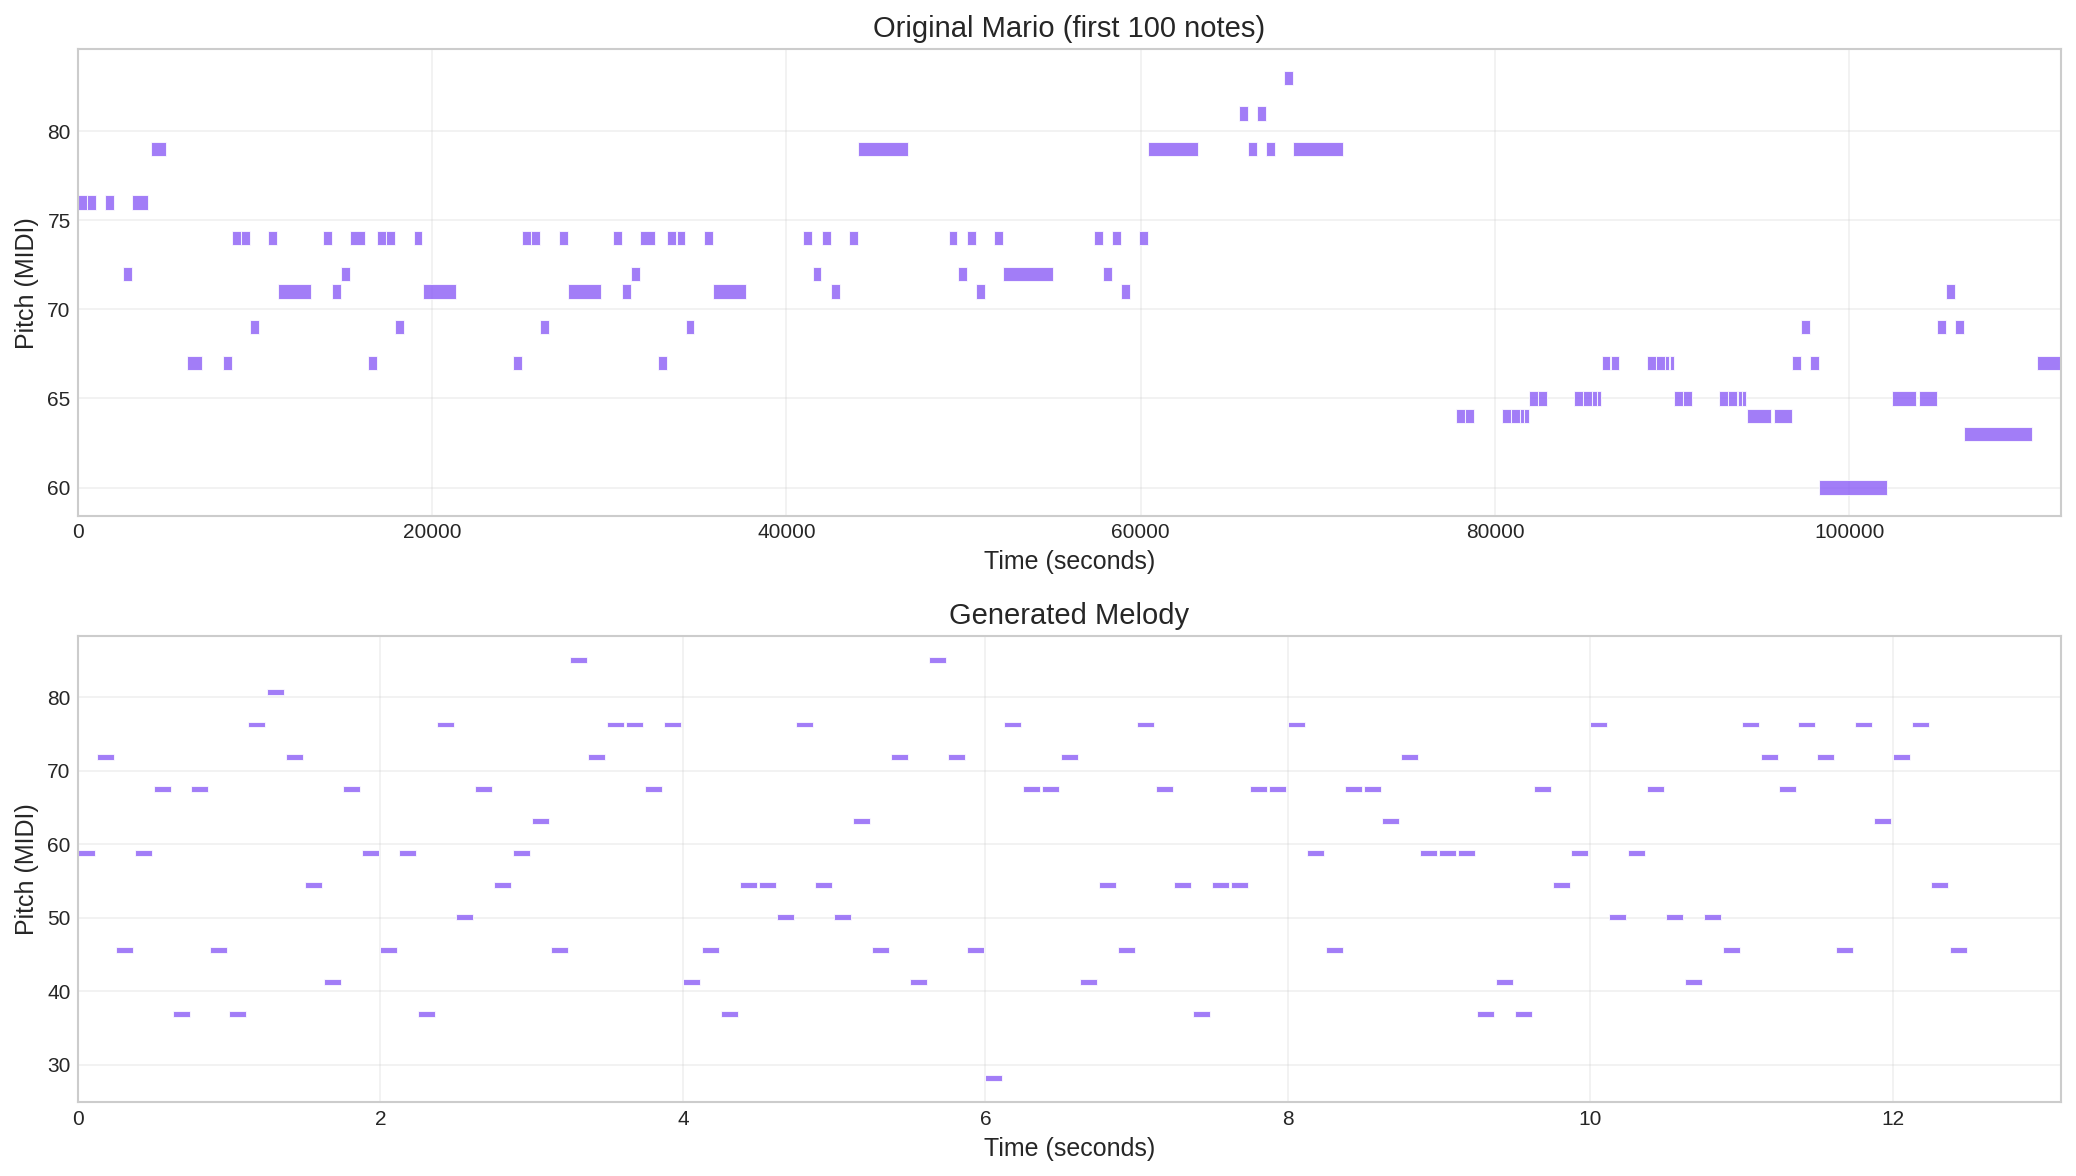

 Piano roll saved to /home/jacopo/Documenti/Trento/QuantumML/MusicProject/notebooks/../results/figures/piano_roll_comparison.png


In [13]:
def plot_piano_roll(notes, title, ax=None):
    """Plot a piano roll visualization."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(14, 5))
    
    for note in notes[:100]:  # First 100 notes
        ax.barh(
            y=note.pitch,
            width=note.duration,
            left=note.start_time,
            height=0.8,
            color='#8B5CF6',
            alpha=0.8,
            edgecolor='white',
            linewidth=0.5
        )
    
    ax.set_xlabel('Time (seconds)')
    ax.set_ylabel('Pitch (MIDI)')
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
    
    return ax

# Compare piano rolls
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=False)

# Original (first 100 notes)
plot_piano_roll(original_notes[:100], 'Original Mario (first 100 notes)', axes[0])
axes[0].set_xlim(0, original_notes[99].start_time + original_notes[99].duration)

# Generated
plot_piano_roll(generated_notes, 'Generated Melody', axes[1])

plt.tight_layout()
save_figure(fig, 'piano_roll_comparison', experiment='exp10')
plt.show()

print(f" Piano roll saved to {FIGURES_DIR / 'piano_roll_comparison.png'}")

##  Summary

### Generated Files:
- `01_qcbm_champion_baseline.mid` - Main generated melody
- `02_qcbm_seed_variation_1.mid` through `02_qcbm_seed_variation_5.mid` - Variations
- `piano_roll_comparison.png` - Visual comparison

### Key Observations:
1. The QCBM successfully learned the pitch distribution of Mario
2. Generated melodies maintain similar statistical properties
3. Each variation is unique due to sampling stochasticity
4. The model captures the "style" but creates novel sequences

### Limitations:
- No temporal structure (notes are i.i.d. samples)
- No harmony/polyphony modeling
- Limited to pitch (no velocity/duration learning)

### Future Work:
- Extend to temporal sequences (Markov QCBM)
- Add velocity and duration encoding
- Experiment with real quantum hardware

In [14]:
print("\n" + "="*70)
print(" MUSIC GENERATION COMPLETE!")
print("="*70)
print("\n   The Quantum Circuit Born Machine has successfully generated")
print("   new musical samples based on the learned distribution.")
print("\n   Open the generated MIDI files to hear your quantum music! ")
print("\n" + "="*70)


 MUSIC GENERATION COMPLETE!

   The Quantum Circuit Born Machine has successfully generated
   new musical samples based on the learned distribution.

   Open the generated MIDI files to hear your quantum music! 



In [15]:
from src.utils.figure_saver import save_current_figure